### 1-Forensics


In [ ]:
import pypdf
from pypdf import PdfReader

#Charger le pdf
reader = PdfReader("Forensics.pdf")
print(f"Nombre de pages: {len(reader.pages)}")
print(reader.pages)

Ignoring wrong pointing object 19 0 (offset 0)
Ignoring wrong pointing object 428 0 (offset 0)
Ignoring wrong pointing object 470 0 (offset 0)
Ignoring wrong pointing object 537 0 (offset 0)


Ignoring wrong pointing object 538 0 (offset 0)


Nombre de pages: 108
[PageObject(0), PageObject(1), PageObject(2), PageObject(3), PageObject(4), PageObject(5), PageObject(6), PageObject(7), PageObject(8), PageObject(9), PageObject(10), PageObject(11), PageObject(12), PageObject(13), PageObject(14), PageObject(15), PageObject(16), PageObject(17), PageObject(18), PageObject(19), PageObject(20), PageObject(21), PageObject(22), PageObject(23), PageObject(24), PageObject(25), PageObject(26), PageObject(27), PageObject(28), PageObject(29), PageObject(30), PageObject(31), PageObject(32), PageObject(33), PageObject(34), PageObject(35), PageObject(36), PageObject(37), PageObject(38), PageObject(39), PageObject(40), PageObject(41), PageObject(42), PageObject(43), PageObject(44), PageObject(45), PageObject(46), PageObject(47), PageObject(48), PageObject(49), PageObject(50), PageObject(51), PageObject(52), PageObject(53), PageObject(54), PageObject(55), PageObject(56), PageObject(57), PageObject(58), PageObject(59), PageObject(60), PageObject(6

In [3]:
#Récuperer texte page par page
pages = []
for i, page in enumerate(reader.pages):
    text = page.extract_text()
    pages.append({
        "numéro_page": i+1,
        "texte": text if text else "",
        "est_vide": len(text.strip()) <50 if text else True
    })

#les 3 premières pages
for p in pages[:3]:
    print(f"\n--- Page {p['numéro_page']} (vide={p['est_vide']}) ---")
    print(p['texte'][:300])


--- Page 1 (vide=False) ---
FORENSICS DANS L'ENTREPRISE
ENJEUX TECHNIQUES ET RÉGLEMENTAIRES
CY ING3 - JANVIER 2026


--- Page 2 (vide=False) ---
CY ING3 - JANVIER 2026 - FORENSICS DANS L'ENTREPRISE
ORDRE DU JOUR
▸Introduction et déﬁnitions 
▸Exemples et cas pratiques de réponse à 
incident 
▸Préparation du TP et modalité de 
l'évaluation 
▸Rechercher et récupérer des données 
▸Méthodes et outils pour la collecte et 
l’analyse de données 
▸Ré

--- Page 3 (vide=False) ---
CY ING3 - JANVIER 2026 - FORENSICS DANS L'ENTREPRISE
INTRODUCTION ET DÉFINITIONS
▸Cartesian Lab est une société de conseil en cybersécurité. 
▸Notre métier consiste à identiﬁer les risques d’origine cyber, de proposer et d’accompagner le déploiement d’un 
plan de traitement et enﬁn de tester et cont


In [5]:
#y'a des pages qui ne servent à rien qu'il faut exclure pour pas fausser le chunking
pages_exclure = [1,2,38,49,50,51,52,53,54,55,56,57,108]
pages_utiles = [
    p for p in pages
    if not p["est_vide"] and p["numéro_page"] not in pages_exclure ]

print(f"Pages totales        : {len(pages)}")
print(f"Pages vides          : {len([p for p in pages if p['est_vide']])}")
print(f"Pages exclues manuellement : {len(pages_exclure)}")
print(f"Pages utiles restantes : {len(pages_utiles)}")




Pages totales        : 108
Pages vides          : 0
Pages exclues manuellement : 13
Pages utiles restantes : 95


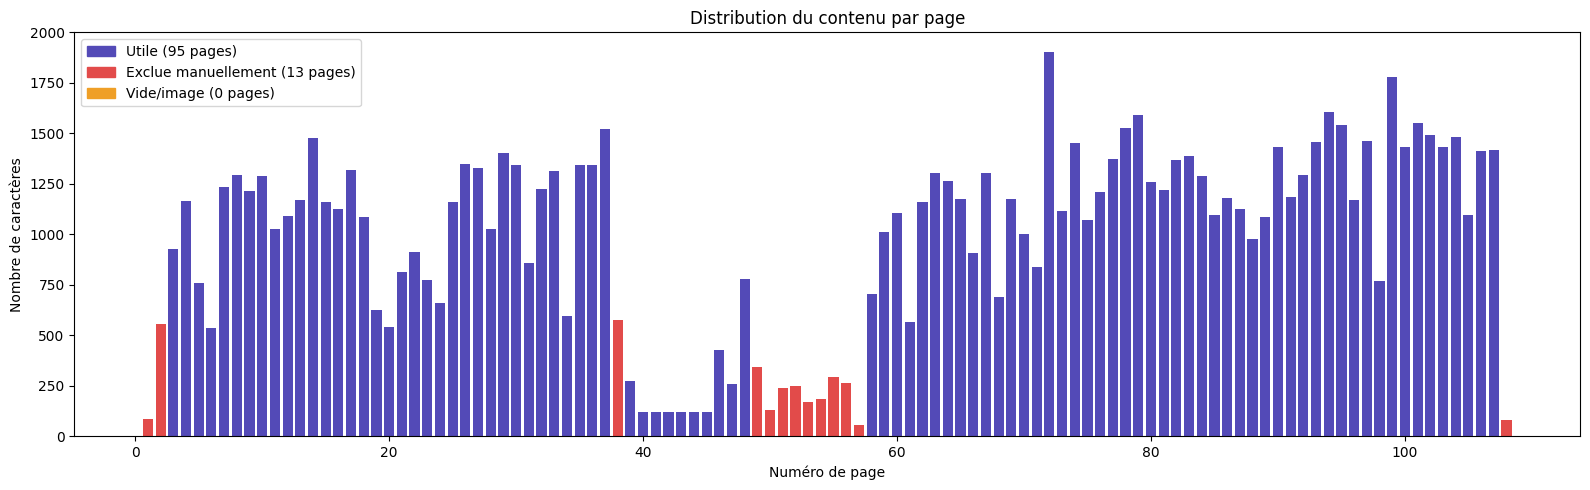

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Couleur par statut de page
couleurs = []
for p in pages:
    if p['numéro_page'] in pages_exclure:
        couleurs.append('#E24B4A')   # rouge = exclue manuellement
    elif p['est_vide']:
        couleurs.append('#EF9F27')   # orange = vide
    else:
        couleurs.append('#534AB7')   # violet = utile

longueurs = [len(p['texte']) for p in pages]

plt.figure(figsize=(16, 5))
plt.bar(range(1, len(pages)+1), longueurs, color=couleurs, width=0.8)

plt.xlabel("Numéro de page")
plt.ylabel("Nombre de caractères")
plt.title("Distribution du contenu par page")

# Légende
legend = [
    mpatches.Patch(color='#534AB7', label=f'Utile ({len(pages_utiles)} pages)'),
    mpatches.Patch(color='#E24B4A', label=f'Exclue manuellement ({len(pages_exclure)} pages)'),
    mpatches.Patch(color='#EF9F27', label=f'Vide/image (0 pages)'),
]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

In [18]:
#Concaténation du texte pour pouvoir faire le chunking
# Transfomer une liste de pages en un seul texte continu pour pas fausser le rag si une même idée est sur deux slides différents
text_complet = ""
for t in pages_utiles:
    text_complet += f"\n{t['texte']}"
print(f"Texte total : {len(text_complet)} caractères")

#Nettoyage du texte des headers, espaces...
import re
def nettoyer (texte):
    texte = re.sub(r'CY ING3 - JANVIER 2026 - FORENSICS DANS L\'ENTREPRISE', '', texte)
    texte = re.sub(r'TABLE RONDE\s*-\s*QUESTIONS', '', texte)
    texte = re.sub(r'BREAK', '', texte)
    texte = re.sub(r'▸', '', texte)
    texte = re.sub(r'\n{3,}', '\n\n', texte)
    texte = re.sub(r' {2,}', ' ', texte)
    return texte.strip()

texte_propre = nettoyer(text_complet)
print(f"Texte total après nettoyage : {len(texte_propre)} caractères")
print(texte_propre[:500])


Texte total : 103023 caractères
Texte total après nettoyage : 97224 caractères
INTRODUCTION ET DÉFINITIONS
Cartesian Lab est une société de conseil en cybersécurité. 
Notre métier consiste à identiﬁer les risques d’origine cyber, de proposer et d’accompagner le déploiement d’un 
plan de traitement et enﬁn de tester et contrôler l’efﬁcacité des mesures de sécurité. Nous intervenons au proﬁt 
d’entreprises ou d’institutions internationales en menant à bien des missions de : 
Tests techniques (Pentests, SoC training, réponse à incident, Forensics). 
Cyber Threat Intelligence.


In [36]:
#Implémentation de la fonction pour chunker
def chunker(texte, taille = 300, overlap=30):
    mots = texte.split()
    chunks = []
    i = 0

    while i < len(mots):
        chunk = mots[i : i+taille]
        chunk_texte = " ".join(chunk)
        chunks.append(chunk_texte)
        i += taille - overlap #On recule de 50
    
    return chunks

chunks_brut = chunker(texte_propre)
print(f"Nombre de chunks :  {len(chunks_brut)}")

Nombre de chunks :  55


In [ ]:
print(type(chunks_brut[0]))     # doit être <class 'str'> pas une liste de liste, keyBERT s'attend à des phrases
print(chunks_brut[0][:200])     # doit être du texte lisible

<class 'str'>
INTRODUCTION ET DÉFINITIONS Cartesian Lab est une société de conseil en cybersécurité. Notre métier consiste à identiﬁer les risques d’origine cyber, de proposer et d’accompagner le déploiement d’un p
Nombre de chunks : 55


In [25]:
#keyBERT pour extraire les MOTS-CLES de chaque chunk
from keybert import KeyBERT

# Charger le modèle multilingue (supporte le français)
kw_model = KeyBERT("paraphrase-multilingual-MiniLM-L12-v2")

print("Modèle chargé !")
print(f"Test sur le chunk 0 :")
print(chunks_brut[0][:200])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé !
Test sur le chunk 0 :
['INTRODUCTION', 'ET', 'DÉFINITIONS', 'Cartesian', 'Lab', 'est', 'une', 'société', 'de', 'conseil', 'en', 'cybersécurité.', 'Notre', 'métier', 'consiste', 'à', 'identiﬁer', 'les', 'risques', 'd’origine', 'cyber,', 'de', 'proposer', 'et', 'd’accompagner', 'le', 'déploiement', 'd’un', 'plan', 'de', 'traitement', 'et', 'enﬁn', 'de', 'tester', 'et', 'contrôler', 'l’efﬁcacité', 'des', 'mesures', 'de', 'sécurité.', 'Nous', 'intervenons', 'au', 'proﬁt', 'd’entreprises', 'ou', 'd’institutions', 'internationales', 'en', 'menant', 'à', 'bien', 'des', 'missions', 'de', ':', 'Tests', 'techniques', '(Pentests,', 'SoC', 'training,', 'réponse', 'à', 'incident,', 'Forensics).', 'Cyber', 'Threat', 'Intelligence.', 'Management', 'et', 'de', 'gouvernance', 'de', 'la', 'SSI.', 'Analyse', 'de', 'risques,', 'conseil,', 'sensibilisation.', 'Audit', '(conformité', 'SI', 'DR,', 'ISO', '27k,', '20', 'CSC,', 'NIST).', 'Cartesian', 'Lab', 'est', 'une', 'société', 'du', 'group

In [51]:
#Termes cyber court et connu: pour éviter le bruit
Termes_Cyber_Courts = {
    "ssd", "hdd", "ram", "cve", "ctf", "ioc", "vpn", 
    "dmz", "soc", "edr", "xdr", "mdm", "usb", "ntp",
    "siem", "ids", "ips", "waf", "acl", "mfa", "ssh",
    "dns", "dhcp", "smb", "rdp", "ftp", "api"
}
#Extraction des mots clés
keywords_chunk = []
for i,chunk in enumerate(chunks_brut):
    keywords = kw_model.extract_keywords(
        chunk,
        keyphrase_ngram_range=(1,2), #Mots de 1 à 2
        use_mmr= True,
        diversity=0.7,
        top_n= 5 #5 keywords par chunk
    )
    keywords_liste = [kw[0] for kw in keywords if len(kw[0]) > 4 or kw[0].lower() in Termes_Cyber_Courts] #kw[0] c'est les mots clés(les 5), kw[1] c'est les scores (des 5 aussi)
    keywords_chunk.append(keywords_liste)

print(f"\n{len(keywords_chunk)} chunks traités")


55 chunks traités


In [52]:
#Test des mots clés extractés
for i in [0, 5, 10, 20]:
    print(f"\n--- Chunk {i} ---")
    print(f"Texte : {chunks_brut[i][:150]}...")
    print(f"Keywords : {keywords_chunk[i]}")


--- Chunk 0 ---
Texte : INTRODUCTION ET DÉFINITIONS Cartesian Lab est une société de conseil en cybersécurité. Notre métier consiste à identiﬁer les risques d’origine cyber, ...
Keywords : ['en cybersécurité', 'tests techniques', 'économique axis', 'gel des', 'type support']

--- Chunk 5 ---
Texte : Ransomware un samedi. Presque tous les serveurs Windows de son DataCenter (DC) sont touchés. Des serveurs de ﬁchiers de plusieurs sites sont touchés é...
Keywords : ['serveurs sauvegarde', 'incident forensics', 'windows touchés', 'dizaine millions', 'ﬁbre optique']

--- Chunk 10 ---
Texte : antérieures. RECHERCHER ET RÉCUPÉRER DES DONNÉES Les bonnes pratiques (qu'on voit rarement appliquées) : Cadrer les usages du matériel professionnel d...
Keywords : ['informatique utiliser', 'durée conservation', 'comptes réattribution', 'nominatives proscrire', 'voit rarement']

--- Chunk 20 ---
Texte : veille, de sortie de veille, d’extinction de l’appareil. Dates, heures et type de connexion ou de dé

In [56]:
#Construire le Json
import json

def constuire(chunks,keywords):
    documents = []
    for i, (chk,kw) in enumerate(zip(chunks, keywords)):
        doc = {
            "id":f"FOR_MISC-CONCEPT--{str(i+1).zfill(3)}",
            "source":"Forensics.pdf",
            "chunk_index":i,
            "domain":"forensics",
            "theme":"misc",
            "level":"intermmediaire",
            "content":chk,
            "keywords":kw,
            "needs_manual":True,
            "related_ids": []
            }
        documents.append(doc)
    return documents


documents = constuire(chunks_brut, keywords_chunk)
#Créer et sauvegarder en JSONl
with open("Forensics.jsonl", "w", encoding="utf-8") as f:
    for doc in documents:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n") #json.dumps convertit un dictionnaire Python en string JSON.


### 2- CVSS (Common Vulnerability Scoring System)

In [2]:
import pypdf
from pypdf import PdfReader

#Charger le pdf
reader_cvss = PdfReader("CVSS.pdf")
print(f"Nombre de Pages : {len(reader_cvss.pages)}")
print(reader_cvss.pages)

Ignoring wrong pointing object 8 0 (offset 0)
Ignoring wrong pointing object 10 0 (offset 0)
Ignoring wrong pointing object 12 0 (offset 0)
Ignoring wrong pointing object 14 0 (offset 0)
Ignoring wrong pointing object 42 0 (offset 0)
Ignoring wrong pointing object 102 0 (offset 0)
Ignoring wrong pointing object 108 0 (offset 0)


Nombre de Pages : 24
[PageObject(0), PageObject(1), PageObject(2), PageObject(3), PageObject(4), PageObject(5), PageObject(6), PageObject(7), PageObject(8), PageObject(9), PageObject(10), PageObject(11), PageObject(12), PageObject(13), PageObject(14), PageObject(15), PageObject(16), PageObject(17), PageObject(18), PageObject(19), PageObject(20), PageObject(21), PageObject(22), PageObject(23)]


In [3]:
#Récupérer texte page par page
pages_cvss = []
for i,page in enumerate(reader_cvss.pages):
    text = page.extract_text()
    pages_cvss.append({
        "numéro_page":i+1,
        "texte": text,
        "est_vide": len(text.strip()) <50 if text else True
    })


#Gardons les pages utiles
pages_exlures_cvss = [2,23,24]
pages_utiles_cvss = [
    p for p in pages_cvss
    if not p["est_vide"] and p["numéro_page"] not in pages_exlures_cvss
]

print(f"Nombre de pages avant: {len(pages_cvss)}")
print(f"Nombre de pages exclues {len(pages_exlures_cvss)}")
print(f"Nombre de pages après: {len(pages_utiles_cvss)}")

Nombre de pages avant: 24
Nombre de pages exclues 3
Nombre de pages après: 21


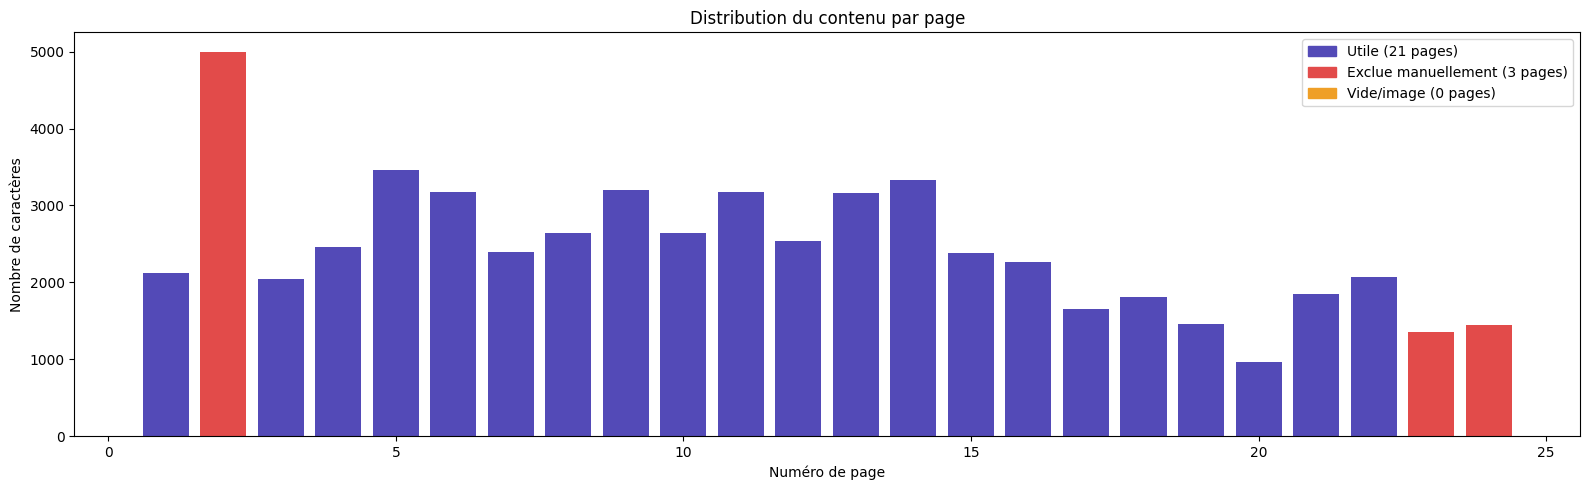

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Couleur par statut de page
couleurs = []
for p in pages_cvss:
    if p['numéro_page'] in pages_exlures_cvss:
        couleurs.append('#E24B4A')   # rouge = exclue manuellement
    elif p['est_vide']:
        couleurs.append('#EF9F27')   # orange = vide
    else:
        couleurs.append('#534AB7')   # violet = utile

longueurs = [len(p['texte']) for p in pages_cvss]

plt.figure(figsize=(16, 5))
plt.bar(range(1, len(pages_cvss)+1), longueurs, color=couleurs, width=0.8)

plt.xlabel("Numéro de page")
plt.ylabel("Nombre de caractères")
plt.title("Distribution du contenu par page")

# Légende
legend = [
    mpatches.Patch(color='#534AB7', label=f'Utile ({len(pages_utiles_cvss)} pages)'),
    mpatches.Patch(color='#E24B4A', label=f'Exclue manuellement ({len(pages_exlures_cvss)} pages)'),
    mpatches.Patch(color='#EF9F27', label=f'Vide/image (0 pages)'),
]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

In [72]:
#Nettoyage du texte:
import re

def nettoyer_texte_cvss(texte):
    texte = re.sub(r'TLP:WHITE', '', texte)
    texte = re.sub(r'CVSS v3\.1 Specification Document - Revision 1', '', texte)
    texte = re.sub(r'https://www\.first\.org/cvss/', '', texte)
    texte = re.sub(r'\d+ of 24', '', texte)
    texte = re.sub(r'\n{3,}', '\n\n', texte)
    texte = re.sub(r' {2,}', ' ', texte)
    
    return texte.strip()

texte_complet_cvss = ""
for t in pages_utiles_cvss:
    texte_complet_cvss += "\n" + nettoyer_texte_cvss(t["texte"])

print(f"\nAperçu :\n{texte_complet_cvss[:400]}")
print(f"Mots par page — moyenne : {len(texte_complet_cvss.split()) // len(pages_utiles_cvss)}")
print(f"Mots total : {len(texte_complet_cvss.split())}")


Aperçu :

Common Vulnerability Scoring System version 3.1 Specification Document Revision 1 The Common Vulnerability Scoring System (CVSS) is an open framework for communicating the characteristics and severity of software vulnerabilities. CVSS consists of three metric groups: Base, Temporal, and Environmental. The Base group represents the intrinsic qualities of a vulnerability that are constant over time
Mots par page — moyenne : 346
Mots total : 7280


In [73]:
#Pour ce document on fait un chunk de 400 avec overlap de 40
def chunker(texte, taille = 400, overlap=40):
    mots = texte.split()
    chunks = []
    i = 0

    while i < len(mots):
        chunk = mots[i : i+taille]
        chunk_texte = " ".join(chunk)
        chunks.append(chunk_texte)
        i += taille - overlap #On recule de 50
    
    return chunks

chunks_brut_cvss = chunker(texte_complet_cvss,taille=400,overlap=40)
print(f"Nombre de chunks : {len(chunks_brut_cvss)}")
print(f"\n--- Aperçu chunk 0 ---")
print(chunks_brut_cvss[0][:300])
print(f"\n--- Aperçu chunk 5 ---")
print(chunks_brut_cvss[5][:300])

Nombre de chunks : 21

--- Aperçu chunk 0 ---
Common Vulnerability Scoring System version 3.1 Specification Document Revision 1 The Common Vulnerability Scoring System (CVSS) is an open framework for communicating the characteristics and severity of software vulnerabilities. CVSS consists of three metric groups: Base, Temporal, and Environmenta

--- Aperçu chunk 5 ---
network or from outside the logically adjacent administrative network domain, use Network. Network should be used even if the attacker is required to be on the same intranet to exploit the vulnerable system (e.g., the attacker can only exploit the vulnerability from inside a corporate network). 2.1.


In [74]:
#KeyBERT pour extraire les mots clés sur CVSS
keywords_cvss = []
for i,chunk in enumerate(chunks_brut_cvss):
    keywords = kw_model.extract_keywords(
        chunk,
        keyphrase_ngram_range=(1, 2),
        use_mmr=True,
        diversity=0.7,
        top_n=5
    )
    keywords_liste = [kw[0] for kw in keywords if len(kw[0])>4 or kw[0].lower() in Termes_Cyber_Courts]
    keywords_cvss.append(keywords_liste)

# Vérifier
for i in [0, 5, 10, 15]:
    print(f"\n--- Chunk {i} ---")
    print(f"Texte : {chunks_brut_cvss[i][:150]}...")
    print(f"Keywords : {keywords_cvss[i]}")


--- Chunk 0 ---
Texte : Common Vulnerability Scoring System version 3.1 Specification Document Revision 1 The Common Vulnerability Scoring System (CVSS) is an open framework ...
Keywords : ['common vulnerability', 'cvss version', 'scoring vector', 'framework communicating', 'time environmental']

--- Chunk 5 ---
Texte : network or from outside the logically adjacent administrative network domain, use Network. Network should be used even if the attacker is required to ...
Keywords : ['use network', 'attacker prepare', 'reliability example', 'metric excludes', 'greatest complex']

--- Chunk 10 ---
Texte : continues to deliver the attack) or persistent (the condition persists even after the attack has completed). Alternatively, the attacker has the abili...
Keywords : ['persists attack', 'availability impacted', 'functional autonomous', 'presents direct', 'metric value']

--- Chunk 15 ---
Texte : metric has the same values as its corresponding Base metric, plus a value of Not Defined. No

In [75]:
documents_cvss = []
for i, (chunk, kws) in enumerate(zip(chunks_brut_cvss, keywords_cvss)):
    doc = {
        "id": f"CVE-{str(i+1).zfill(3)}",
        "source": "CVSS.pdf",
        "chunk_index": i,
        "domain": "cve_cvss",
        "content": chunk,
        "keywords": kws,
        "needs_manual": True,
        "related_ids": []
    }
    documents_cvss.append(doc)

with open("forensics.jsonl", "a", encoding="utf-8", newline="\n") as f:
    for doc in documents_cvss:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")

print(f"Chunks CVSS ajoutés : {len(documents_cvss)}")

# Vérifier le total
with open("forensics.jsonl", "r", encoding="utf-8") as f:
    total = len(f.readlines())
print(f"Total chunks dans le fichier : {total}")

Chunks CVSS ajoutés : 21
Total chunks dans le fichier : 97


### 3- Analyse de Logs

In [6]:
from pypdf import PdfReader

reader_log = PdfReader("Logs.pdf")
reader_log.decrypt("")

print(f"Nombre de pages : {len(reader_log.pages)}")

Nombre de pages : 117


In [8]:
total_pages = len(reader_log.pages)
PAGES_EXCLURE_LOGS = list(range(1, 15)) + list(range(total_pages - 3, total_pages + 1))


pages_logs = []
for i, page in enumerate(reader_log.pages):
    text = page.extract_text()
    pages_logs.append({
        "numéro_page": i + 1,
        "texte": text if text else "",
        "est_vide": len(text.strip()) < 50 if text else True
    })

#On filtre
pages_utiles_logs = [
    p for p in pages_logs
    if not p["est_vide"] and p["numéro_page"] not in PAGES_EXCLURE_LOGS
]

print(f"Pages totales : {len(pages_logs)}")
print(f"Pages exclues : {len(PAGES_EXCLURE_LOGS)}")
print(f"Pages utiles  : {len(pages_utiles_logs)}")


Pages totales : 117
Pages exclues : 18
Pages utiles  : 99
